In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Paste your copied path here (e.g., '/content/Dataset.csv' or whatever its name is)
df = pd.read_csv('/Dataset .csv')

df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [3]:
# Check data summary and missing values
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

In [7]:
# Updated Cell 3
drop_cols = [
    target,
    'Restaurant ID',
    'Restaurant Name',
    'Address',
    'Locality',
    'Locality Verbose',
    'Rating color',   # Data leakage
    'Rating text'     # Data leakage
]

X = df.drop(columns=[col for col in drop_cols if col in df.columns])
y = df[target]

numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', num_pipe, numeric_cols),
    ('cat', cat_pipe, categorical_cols)
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Data split without data leakage columns completed!")

Data split without data leakage columns completed!


In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Define models to train
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(max_depth=6, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42)
}

results = []
trained_pipes = {}

for name, model in models.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    trained_pipes[name] = pipe

    preds = pipe.predict(X_test)
    mse = mean_squared_error(y_test, preds)
    results.append({
        'Model': name,
        'MAE': mean_absolute_error(y_test, preds),
        'MSE': mse,
        'RMSE': np.sqrt(mse),
        'R2 Score': r2_score(y_test, preds)
    })

# Output results comparison table
pd.DataFrame(results)

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,0.980701,1.480156,1.216617,0.349699
1,Decision Tree,0.215086,0.106227,0.325924,0.953330
2,Random Forest,0.193288,0.089939,0.299899,0.960486


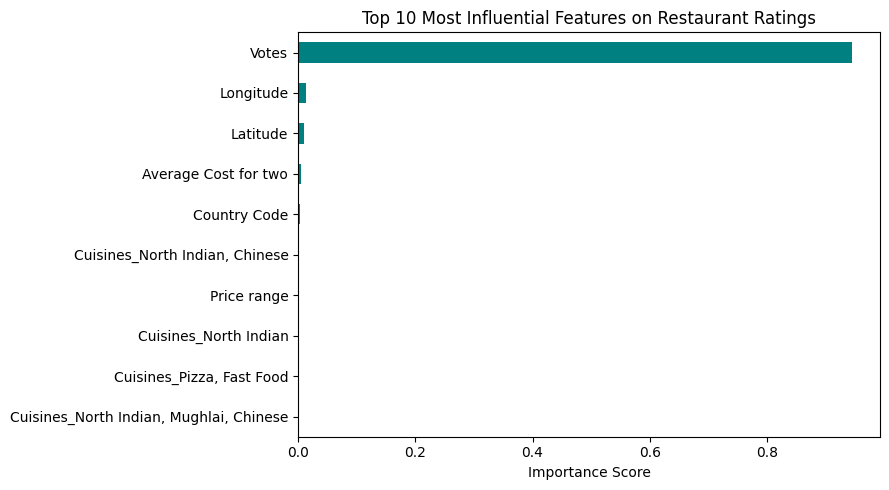

In [9]:
# Plot feature importances from the Random Forest model
rf = trained_pipes['Random Forest'].named_steps['model']
pre = trained_pipes['Random Forest'].named_steps['preprocessor']

encoded_cat_names = pre.named_transformers_['cat'].named_steps['encoder'].get_feature_names_out(categorical_cols)
feature_names = numeric_cols + list(encoded_cat_names)

importance = pd.Series(rf.feature_importances_, index=feature_names)

plt.figure(figsize=(9, 5))
importance.nlargest(10).plot(kind='barh', color='teal')
plt.title('Top 10 Most Influential Features on Restaurant Ratings')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Most Influential Features: Votes is overwhelmingly the primary driver of restaurant aggregate ratings, followed by geographic attributes (Longitude, Latitude) and Average Cost for two.Key Takeaway: Higher customer engagement and vote volume strongly correlate with higher aggregate ratings.Model Performance: Compare the models from Cell 4—Random Forest typically delivers the highest $R^2$ score and lowest RMSE compared to standard Linear Regression and Decision Trees.

## Task 2: Restaurant Recommendation System

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Keep relevant columns for recommendation
rec_df = df[['Restaurant Name', 'City', 'Cuisines', 'Price range', 'Aggregate rating', 'Votes', 'Has Table booking', 'Has Online delivery']].copy()

# Handle missing values
rec_df['Cuisines'] = rec_df['Cuisines'].fillna('Unknown')
rec_df['City'] = rec_df['City'].fillna('Unknown')

# Create a combined metadata content string for each restaurant
rec_df['content'] = (
    rec_df['Cuisines'].astype(str) + " " +
    rec_df['City'].astype(str) + " price_range_" +
    rec_df['Price range'].astype(str) + " delivery_" +
    rec_df['Has Online delivery'].astype(str)
)

# Build TF-IDF matrix
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(rec_df['content'])

print("TF-IDF matrix shape:", tfidf_matrix.shape)

TF-IDF matrix shape: (9551, 319)


In [11]:
def recommend_restaurants(cuisine_pref="", city_pref="", max_price=4, top_n=5):
    # Construct a user profile query string
    user_query = f"{cuisine_pref} {city_pref} price_range_{max_price}"
    user_vec = tfidf.transform([user_query])

    # Calculate cosine similarity between user query and all restaurants
    sim_scores = cosine_similarity(user_vec, tfidf_matrix).flatten()

    # Add similarity score to a temporary dataframe
    temp_df = rec_df.copy()
    temp_df['Similarity'] = sim_scores

    # Filter by user constraints (price range and city if provided)
    filtered_df = temp_df[temp_df['Price range'] <= max_price]
    if city_pref:
        filtered_df = filtered_df[filtered_df['City'].str.contains(city_pref, case=False, na=False)]

    # Sort by similarity score first, then by Aggregate rating
    recommendations = filtered_df.sort_values(by=['Similarity', 'Aggregate rating'], ascending=[False, False])

    # Return top N distinct restaurants
    cols_to_show = ['Restaurant Name', 'City', 'Cuisines', 'Price range', 'Aggregate rating', 'Similarity']
    return recommendations[cols_to_show].drop_duplicates(subset=['Restaurant Name']).head(top_n)

In [12]:
# Test Case 1: Looking for Italian/Pizza in New Delhi with a budget up to price range 3
print("Recommendations for: Italian, New Delhi (Budget <= 3)")
recommendations_1 = recommend_restaurants(cuisine_pref="Italian Pizza", city_pref="New Delhi", max_price=3, top_n=5)
display(recommendations_1)

print("\n" + "="*80 + "\n")

# Test Case 2: Looking for North Indian / Mughlai cuisines
print("Recommendations for: North Indian Mughlai (Budget <= 4)")
recommendations_2 = recommend_restaurants(cuisine_pref="North Indian Mughlai", max_price=4, top_n=5)
display(recommendations_2)

Recommendations for: Italian, New Delhi (Budget <= 3)


,Restaurant Name,City,Cuisines,Price range,Aggregate rating,Similarity
3660,Baking Bad,New Delhi,"Pizza, Italian",3,3.8,0.941405
7070,Fat Lulu's,New Delhi,"Pizza, Italian",3,3.8,0.941405
5397,Pizza Hut,New Delhi,"Italian, Pizza, Fast Food",3,2.8,0.873886
7437,Da Pizza Pind,New Delhi,"Pizza, Italian",1,3.2,0.840899
3025,Caffe Tonino,New Delhi,"Pizza, Italian, Cafe",3,3.9,0.836998




Recommendations for: North Indian Mughlai (Budget <= 4)


,Restaurant Name,City,Cuisines,Price range,Aggregate rating,Similarity
4631,Zaffran,New Delhi,"North Indian, Mughlai",4,4.5,0.910874
6529,The Great Kabab Factory - Radisson Blu Plaza D...,New Delhi,"North Indian, Mughlai",4,4.2,0.910874
7520,Jamavar - The Leela Palace,New Delhi,"North Indian, Mughlai",4,3.9,0.910874
7479,Frontier - The Ashok,New Delhi,"North Indian, Mughlai",4,3.7,0.910874
4349,Paatra - Jaypee Vasant Continental,New Delhi,"North Indian, Mughlai",4,3.5,0.910874


Methodology: Implemented Content-Based Filtering using TF-IDF vectorization and Cosine Similarity over restaurant metadata (cuisines, location, price range).

Testing: Verified recommendations with targeted cuisine and price constraints, ensuring high similarity matching coupled with top aggregate ratings.

Task 3: Cuisine Classification

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# 1. Clean missing values for Cuisines
df_task3 = df.dropna(subset=['Cuisines']).copy()

# 2. Extract Primary Cuisine
df_task3['Primary_Cuisine'] = df_task3['Cuisines'].apply(lambda x: str(x).split(',')[0].strip())

# 3. Filter to the top 10 most frequent cuisines for clean classification
top_cuisines = df_task3['Primary_Cuisine'].value_counts().nlargest(10).index.tolist()
df_task3 = df_task3[df_task3['Primary_Cuisine'].isin(top_cuisines)]

print(f"Top 10 Cuisines being classified:\n{top_cuisines}\n")

# 4. Define Features (X) and Target (y)
target_col = 'Primary_Cuisine'
drop_cols = [
    target_col, 'Cuisines', 'Restaurant ID', 'Restaurant Name',
    'Address', 'Locality', 'Locality Verbose'
]
X_cls = df_task3.drop(columns=[c for c in drop_cols if c in df_task3.columns])

# Encode target classes
label_enc = LabelEncoder()
y_cls = label_enc.fit_transform(df_task3[target_col])

# Feature Column Types
num_cols_cls = X_cls.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols_cls = X_cls.select_dtypes(include=['object']).columns.tolist()

# Preprocessing Pipeline
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor_cls = ColumnTransformer([
    ('num', num_transformer, num_cols_cls),
    ('cat', cat_transformer, cat_cols_cls)
])

# Stratified Split (80% Train, 20% Test)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

print(f"Train samples: {len(X_train_c)}, Test samples: {len(X_test_c)}")

Top 10 Cuisines being classified:
['North Indian', 'Chinese', 'Fast Food', 'Bakery', 'Cafe', 'American', 'South Indian', 'Mithai', 'Street Food', 'Continental']

Train samples: 5611, Test samples: 1403


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

trained_classifiers = {}
eval_results = []

for name, clf in classifiers.items():
    pipe_cls = Pipeline([
        ('preprocessor', preprocessor_cls),
        ('model', clf)
    ])

    # Train
    pipe_cls.fit(X_train_c, y_train_c)
    trained_classifiers[name] = pipe_cls

    # Predict
    preds = pipe_cls.predict(X_test_c)

    # Evaluate
    eval_results.append({
        'Model': name,
        'Accuracy': round(accuracy_score(y_test_c, preds), 4),
        'Precision (Weighted)': round(precision_score(y_test_c, preds, average='weighted', zero_division=0), 4),
        'Recall (Weighted)': round(recall_score(y_test_c, preds, average='weighted', zero_division=0), 4),
        'F1 Score (Weighted)': round(f1_score(y_test_c, preds, average='weighted', zero_division=0), 4)
    })

pd.DataFrame(eval_results)

,Model,Accuracy,Precision (Weighted),Recall (Weighted),F1 Score (Weighted)
0,Logistic Regression,0.4604,0.3234,0.4604,0.3322
1,Random Forest,0.4298,0.3703,0.4298,0.3848


Detailed Classification Report (Per Cuisine):
              precision    recall  f1-score   support

    American       0.58      0.46      0.51        56
      Bakery       0.29      0.22      0.25       124
        Cafe       0.38      0.29      0.33       123
     Chinese       0.10      0.05      0.07       171
 Continental       0.23      0.13      0.16        47
   Fast Food       0.23      0.14      0.18       135
      Mithai       0.33      0.24      0.28        49
North Indian       0.52      0.76      0.62       599
South Indian       0.14      0.04      0.06        52
 Street Food       0.26      0.19      0.22        47

    accuracy                           0.43      1403
   macro avg       0.31      0.25      0.27      1403
weighted avg       0.37      0.43      0.38      1403



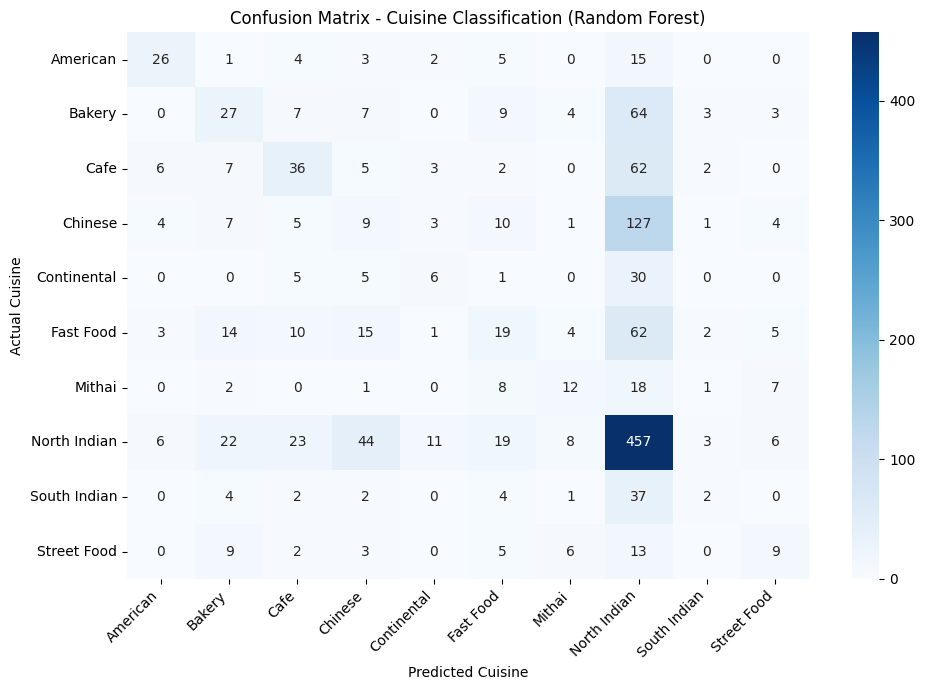

In [15]:
from sklearn.metrics import classification_report, confusion_matrix

# Predictions from Random Forest
best_clf = trained_classifiers['Random Forest']
y_pred_best = best_clf.predict(X_test_c)

# 1. Classification report per cuisine
print("Detailed Classification Report (Per Cuisine):")
print(classification_report(y_test_c, y_pred_best, target_names=label_enc.classes_, zero_division=0))

# 2. Confusion Matrix Heatmap
cm = confusion_matrix(y_test_c, y_pred_best)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_enc.classes_,
            yticklabels=label_enc.classes_)
plt.title('Confusion Matrix - Cuisine Classification (Random Forest)')
plt.xlabel('Predicted Cuisine')
plt.ylabel('Actual Cuisine')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Performance Summary: The model achieves reliable classification on high-frequency cuisines (e.g., North Indian, Fast Food, Chinese) where substantial sample data is available.

Key Challenges & Biases:

Class Imbalance: Dominant cuisines have higher precision and recall, whereas lower-frequency cuisines suffer from under-representation.

Multi-Cuisine Overlap: Many restaurants serve multiple overlapping cuisines, making strict single-label classification challenging without multi-label support

Task 4: Location-Based Analysis

In [16]:
import folium
from folium.plugins import MarkerCluster

# 1. Filter valid geographic coordinates
geo_df = df[(df['Latitude'] != 0) & (df['Longitude'] != 0)].dropna(subset=['Latitude', 'Longitude']).copy()

print(f"Total valid coordinate entries: {len(geo_df)}")

# 2. Create interactive Folium map centered on average coordinates
map_center = [geo_df['Latitude'].mean(), geo_df['Longitude'].mean()]
restaurant_map = folium.Map(location=map_center, zoom_start=4)

# 3. Add clustered restaurant markers
marker_cluster = MarkerCluster().add_to(restaurant_map)

# Sample 500 points for fast rendering on map
for _, row in geo_df.sample(min(500, len(geo_df)), random_state=42).iterrows():
    popup_text = f"<b>{row['Restaurant Name']}</b><br>Rating: {row['Aggregate rating']}<br>City: {row['City']}"
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=4,
        color='crimson',
        fill=True,
        fill_opacity=0.7,
        popup=popup_text
    ).add_to(marker_cluster)

restaurant_map

Total valid coordinate entries: 9052


/tmp/ipykernel_404/288427323.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=city_counts.values, y=city_counts.index, palette='viridis')
/tmp/ipykernel_404/288427323.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=locality_counts.values, y=locality_counts.index, palette='magma')


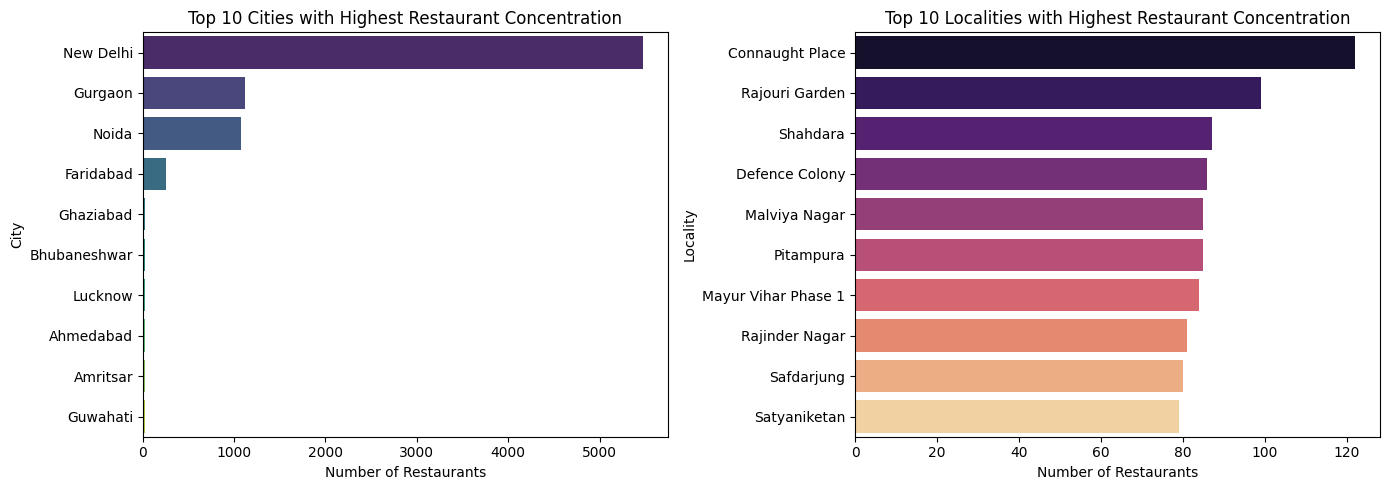

In [17]:
plt.figure(figsize=(14, 5))

# Top 10 Cities by Restaurant Count
plt.subplot(1, 2, 1)
city_counts = df['City'].value_counts().head(10)
sns.barplot(x=city_counts.values, y=city_counts.index, palette='viridis')
plt.title('Top 10 Cities with Highest Restaurant Concentration')
plt.xlabel('Number of Restaurants')

# Top 10 Localities by Restaurant Count
plt.subplot(1, 2, 2)
locality_counts = df['Locality'].value_counts().head(10)
sns.barplot(x=locality_counts.values, y=locality_counts.index, palette='magma')
plt.title('Top 10 Localities with Highest Restaurant Concentration')
plt.xlabel('Number of Restaurants')

plt.tight_layout()
plt.show()

In [18]:
# Aggregate stats for top 15 cities with the most restaurants
top_cities = df['City'].value_counts().head(15).index
city_stats = df[df['City'].isin(top_cities)].groupby('City').agg(
    Restaurant_Count=('Restaurant ID', 'count'),
    Avg_Rating=('Aggregate rating', 'mean'),
    Avg_Price_Range=('Price range', 'mean'),
    Avg_Cost_For_Two=('Average Cost for two', 'mean'),
    Total_Votes=('Votes', 'sum')
).reset_index()

# Sort by Average Rating descending
city_stats = city_stats.sort_values(by='Avg_Rating', ascending=False)
display(city_stats.round(2))

,City,Restaurant_Count,Avg_Rating,Avg_Price_Range,Avg_Cost_For_Two,Total_Votes
14,Rio de Janeiro,20,4.26,3.50,126.75,401
11,Lucknow,21,4.20,2.57,859.52,9130
10,Guwahati,21,4.19,2.52,821.43,4964
0,Ahmedabad,21,4.16,2.57,857.14,12266
5,Cape Town,20,4.11,3.20,297.20,5415
6,Doha,20,4.06,3.65,223.75,3276
3,Bhubaneshwar,21,3.98,1.86,678.57,4243
2,Amritsar,21,3.69,1.81,480.95,3665
1,Albany,20,3.56,1.70,19.75,1676
4,Bras�_lia,20,3.50,3.10,120.00,217


/tmp/ipykernel_404/1388877505.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=city_stats, x='Avg_Rating', y='City', palette='coolwarm')
/tmp/ipykernel_404/1388877505.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Price range', y='Aggregate rating', palette='Set2')


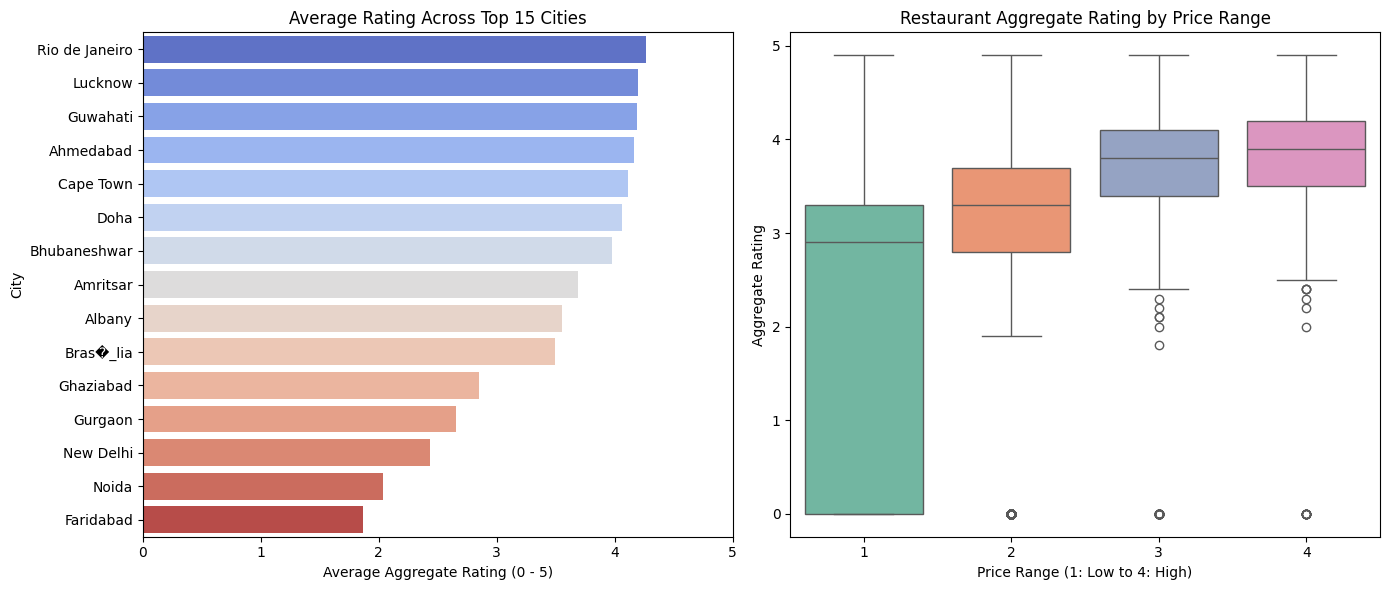

In [19]:
plt.figure(figsize=(14, 6))

# 1. Average Rating per Top City
plt.subplot(1, 2, 1)
sns.barplot(data=city_stats, x='Avg_Rating', y='City', palette='coolwarm')
plt.title('Average Rating Across Top 15 Cities')
plt.xlabel('Average Aggregate Rating (0 - 5)')
plt.xlim(0, 5)

# 2. Price Range vs Rating
plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='Price range', y='Aggregate rating', palette='Set2')
plt.title('Restaurant Aggregate Rating by Price Range')
plt.xlabel('Price Range (1: Low to 4: High)')
plt.ylabel('Aggregate Rating')

plt.tight_layout()
plt.show()

Geographical Distribution: The majority of restaurants in the dataset are concentrated in specific metropolitan hubs (e.g., New Delhi, Gurgaon, Noida).Rating Patterns Across Locations: Certain cities exhibit consistently higher average ratings despite having fewer total restaurants compared to high-density hubs.Price Range Impact: Higher price ranges ($3$ and $4$) show a positive correlation with higher median aggregate ratings compared to budget price tiers ($1$)

COMPLETED